In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from scipy.spatial.distance import pdist

In [2]:
training_configs = np.load("LJ13_configs.npy");

In [3]:
com = training_configs.mean(axis=1, keepdims=True)

training_configs_centered = training_configs - com

The translation has been taken care of here

In [4]:
training_configs_centered_tensor = torch.tensor(training_configs_centered, dtype=torch.float32)

print(training_configs_centered_tensor.shape)

torch.Size([24994, 13, 3])


In [5]:
class MessageMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class FeatureMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class CoordMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        torch.nn.init.xavier_uniform_(
            self.net[-1].weight,
            gain=0.001
        )

        torch.nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class EGNNLayer(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.message_mlp = MessageMLP(hidden_dim)

        self.feature_mlp = FeatureMLP(hidden_dim)

        self.coord_mlp = CoordMLP(hidden_dim)

    def forward(self, x, h, sigma):

        N = x.shape[1]

        diff = x[:,:,None,:] - x[:,None,:,:]
        dist2 = (diff**2).sum(dim=-1, keepdim=True)

        hi = h[:,:,None,:]
        hi = hi.expand(-1,-1,N,-1)

        hj = h[:,None,:,:]
        hj = hj.expand(-1,N,-1,-1)

        sigma_pair = sigma[:,None,None,:]
        sigma_pair = sigma_pair.expand(-1,N,N,-1)

        message_input = torch.cat([hi, hj, dist2, sigma_pair], dim=-1)

        messages = self.message_mlp(message_input)

        agg_messages = messages.sum(dim=2)

        feature_input = torch.cat([h, agg_messages], dim=-1)

        feature_update = self.feature_mlp(feature_input)

        h_new = h + feature_update

        coord_weights = self.coord_mlp(message_input)

        coord_update = diff * coord_weights

        delta_x = coord_update.sum(dim=2)

        delta_x = delta_x / x.shape[1]

        x_new = x + delta_x

        return x_new, h_new, delta_x

    

In [ ]:
class ScoreNetwork(nn.Module):

    def __init__(
        self,
        hidden_dim=64,
        num_layers=3
    ):
        super().__init__()

        self.embedding = nn.Linear(1, hidden_dim)

        self.layers = nn.ModuleList(
            [
                EGNNLayer(hidden_dim)
                for _ in range(num_layers)
            ]
        )


    def forward(self, x, sigma):

        atom_features = torch.ones(x.shape[0], x.shape[1], 1)

        h = self.embedding(atom_features)

        score = torch.zeros_like(x)

        for layer in self.layers:

            x, h, delta_x = layer(x, h, sigma)

            score = score + delta_x


        return score


In [10]:
X = training_configs_centered.reshape(training_configs_centered.shape[0],39)
X = torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.01

print("sigma_max:", sigma_max)

sigma_max: 6.440439591617135


Previously, i.e. before removing the translation, sigma_max was 82. It has improved significantly.

In [11]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [12]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))

In [13]:
def train_model(
  optimizer_name="Adam",
  lr = 1e-4,
  batch_size = 100,
  width = 64,
  depth = 3,
  num_epochs = 600   
):
    dataset = TensorDataset(training_configs_centered_tensor)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    model = ScoreNetwork(hidden_dim=width,num_layers=depth)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            sigma_expanded = sigma.view(-1,1,1)

            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma_expanded * noise
            
            target = -noise / sigma_expanded 

            score_pred = model(x_noisy, sigma)

            loss_per_sample = ((score_pred - target) ** 2).sum(dim=(1,2))

            weights = sigma.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss = {avg_loss:.6f}")

    return model, loss_history

During the backprop, the norm of the gradients have been clipped, in other words, it scaled down the gradients. Without this, the training became extremely unstable at higher epochs, the gradients became very large and so did the optimizing step. 

In [33]:
model, loss_history = train_model()

Epoch    0 | Loss = 30.601261
Epoch   10 | Loss = 23.706614
Epoch   20 | Loss = 17.450984
Epoch   30 | Loss = 16.859661
Epoch   40 | Loss = 16.615474
Epoch   50 | Loss = 16.545303
Epoch   60 | Loss = 16.401085
Epoch   70 | Loss = 16.386745
Epoch   80 | Loss = 16.418087
Epoch   90 | Loss = 16.179512
Epoch  100 | Loss = 16.153456
Epoch  110 | Loss = 16.038361
Epoch  120 | Loss = 15.992104
Epoch  130 | Loss = 16.081710
Epoch  140 | Loss = 15.827281
Epoch  150 | Loss = 15.839799
Epoch  160 | Loss = 15.810704
Epoch  170 | Loss = 15.769743
Epoch  180 | Loss = 15.865126
Epoch  190 | Loss = 15.587921
Epoch  200 | Loss = 15.577191
Epoch  210 | Loss = 15.621240
Epoch  220 | Loss = 15.527474
Epoch  230 | Loss = 15.492297
Epoch  240 | Loss = 15.461313
Epoch  250 | Loss = 15.486645
Epoch  260 | Loss = 15.574286
Epoch  270 | Loss = 15.398879
Epoch  280 | Loss = 15.595015
Epoch  290 | Loss = 15.444475
Epoch  300 | Loss = 15.470671
Epoch  310 | Loss = 15.393336
Epoch  320 | Loss = 15.389055
Epoch  330

Text(0, 0.5, 'Loss')

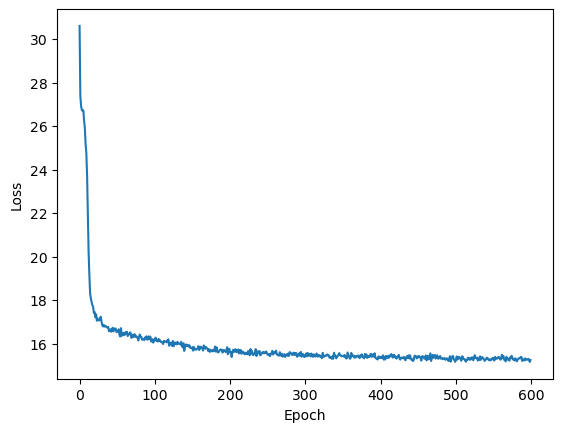

In [17]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")


In [18]:
print(loss_history)

[30.60126092529297, 27.38988722229004, 26.929067321777342, 26.738323806762697, 26.703205551147462, 26.720448204040526, 26.251362243652345, 25.91206364440918, 25.16329630279541, 24.750445976257325, 23.70661422729492, 21.82043221282959, 20.199572494506835, 19.157376502990722, 18.31402681350708, 18.064750621795653, 17.91770966720581, 17.762428295135496, 17.689564094543456, 17.412477058410644, 17.45098379135132, 17.20501348876953, 17.344965465545656, 17.04970911407471, 17.145997451782225, 17.094599704742432, 17.062451404571533, 17.08290027618408, 17.23512553024292, 17.044416431427003, 16.85966072845459, 16.790380668640136, 16.86434204864502, 16.779018115997314, 16.814896141052245, 16.802753715515138, 16.75005097579956, 16.748905261993407, 16.768310600280763, 16.56640386581421, 16.615473907470705, 16.656171211242675, 16.543370449066163, 16.619162990570068, 16.730622821807863, 16.558980167388917, 16.674002513885497, 16.696381019592284, 16.68894116592407, 16.52831852722168, 16.545303119659422

In [19]:
def predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
):

    model.eval()

    x = torch.randn(n_samples, 13, 3) * sigma_max

    dt = 1.0 / n_steps
    sqrt_dt = np.sqrt(dt)


    with torch.no_grad():

        for i in range(n_steps):

            t = 1 - i / n_steps

            t_tensor = torch.full((n_samples,1), t)

            sigma = get_sigma(t_tensor)

            g_val = g(t_tensor).view(-1, 1, 1)

            score = model(x, sigma)

            if torch.isnan(score).any():
                    print(f"NaN in score at step {i}, t={t:.4f}, sigma={sigma[0].item():.4f}")
                    
                    break

            noise = torch.randn_like(x)

            x = (x + (g_val**2) * score * dt + g_val * sqrt_dt * noise)

            x = x - x.mean(dim=1, keepdim=True)
            if torch.isnan(x).any():
                    print(f"NaN in x (predictor) at step {i}")
                    break

            for _ in range(n_corrector):

                score = model(x, sigma)

                noise = torch.randn_like(x)

                score_norm = torch.norm(score.reshape(n_samples, -1), dim=1).mean()


                noise_norm = torch.norm(noise.reshape(n_samples,-1), dim=1).mean()

                if score_norm.item() == 0.0 or torch.isnan(score_norm):
                        print(f"score_norm degenerate at step {i}: {score_norm.item()}")
                        break

                eps = (2 * (snr * noise_norm / score_norm)**2)
                #eps = torch.clamp(eps, max=0.05)       

                x = (x + eps * score + torch.sqrt(2*eps) * noise)
                x = x - x.mean(dim=1, keepdim=True)

                if torch.isnan(x).any():
                        print(f"NaN in x (corrector) at step {i}")
                        break


    return x

In [20]:
samples = predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
)

In [30]:
print("NaNs present:", torch.isnan(samples).any().item())
print("Infs present:", torch.isinf(samples).any().item())
print("Sample range:", samples.min().item(), samples.max().item())
print("COM check:", samples.mean(dim=1).abs().max().item())

NaNs present: False
Infs present: False
Sample range: -1.2843971252441406 1.3136999607086182
COM check: 4.12647551684131e-08


No NaNs and Infs present in the generated samples. Hence indicating that none of the samples contain collapsed atoms.

In [22]:
def lj_energy(coords):

    N = coords.shape[0]

    energy = 0.0

    for i in range(N):
        for j in range(i + 1, N):

            r = torch.norm(coords[i] - coords[j])

            inv_r6 = (1.0 / r) ** 6
            inv_r12 = inv_r6 ** 2

            energy += 4 * (inv_r12 - inv_r6)

    return energy

In [23]:
generated_energies = []

for sample in samples:

    E = lj_energy(sample)

    generated_energies.append(E.item())

generated_energies = np.array(generated_energies)

In [24]:
training_energies = []

for sample in training_configs_centered_tensor:

    E = lj_energy(sample)

    training_energies.append(E.item())

training_energies = np.array(training_energies)

In [25]:
print("Training")
print(training_energies.min())
print(training_energies.max())
print(training_energies.mean())

print()

print("Generated")
print(generated_energies.min())
print(generated_energies.max())
print(generated_energies.mean())

Training
-43.76762771606445
-40.26786804199219
-42.526261944498756

Generated
-43.50892639160156
-33.446372985839844
-41.97585844802857


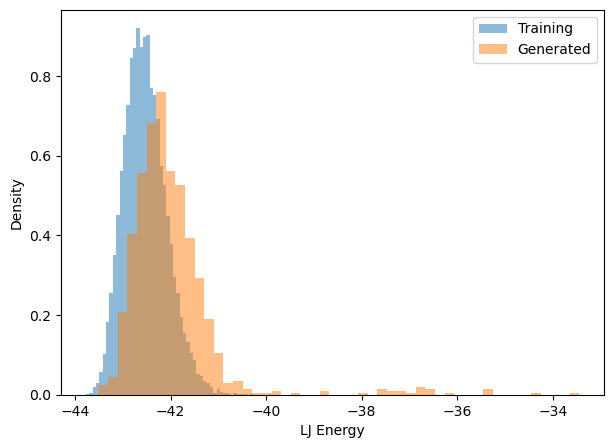

In [26]:
plt.figure(figsize=(7,5))

plt.hist(training_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Training")

plt.hist(generated_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Generated")

plt.xlabel("LJ Energy")
plt.ylabel("Density")
plt.legend()
plt.show()

Although energy distributions do not completely match, but it shows a significant improvement compared to the previous model

In [27]:
def pairwise_distances(configs):

    distances = []

    for config in configs:

        for i in range(13):
            for j in range(i+1,13):

                r = torch.norm(config[i]-config[j])

                distances.append(r.item())

    return np.array(distances)

In [28]:
training_distances = pairwise_distances(training_configs_centered_tensor)

generated_distances = pairwise_distances(samples)

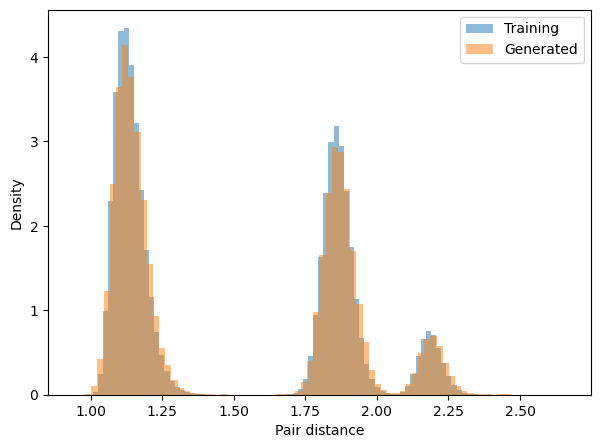

In [29]:
plt.figure(figsize=(7,5))

plt.hist(
    training_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Pair distance")
plt.ylabel("Density")
plt.legend()

plt.show()

The pairwise distances comparison looks great in my opinion. The distances do match.

In [35]:
import torch.nn.functional as F

true_norms = []
learned_norms = []
cosine_similarities = []
norm_percentage_differences = []

n_test = 500
Temp = 0.10
beta = 1.0 / Temp

for k in range(n_test):

    x = training_configs_centered_tensor[k].clone()
    x.requires_grad_(True)

    U = lj_energy(x)

    grad_U = torch.autograd.grad(U, x)[0]

    true_score = -beta * grad_U

    sigma = torch.tensor([[sigma_min]],dtype=torch.float32)

    with torch.no_grad():
        learned_score = model(x.unsqueeze(0), sigma)[0]


    true_norm = torch.norm(true_score)
    learned_norm = torch.norm(learned_score)

    true_norms.append(true_norm.item())
    learned_norms.append(learned_norm.item())


    cosine = F.cosine_similarity(true_score.flatten(), learned_score.flatten(), dim=0)

    cosine_similarities.append(cosine.item())

mean_true_norm = sum(true_norms) / len(true_norms)

mean_learned_norm = sum(learned_norms) / len(learned_norms)

mean_cosine = (sum(cosine_similarities) / len(cosine_similarities))

norm_percentage_difference = (abs(mean_learned_norm - mean_true_norm) / mean_true_norm * 100)


print("Mean true score norm:",
      mean_true_norm)

print("Mean learned score norm:",
      mean_learned_norm)

print("Mean cosine similarity:",
      mean_cosine)

print("Mean norm percentage difference:",
      norm_percentage_difference, "%")


Mean true score norm: 224.19168452453613
Mean learned score norm: 170.4297180480957
Mean cosine similarity: 0.9700279757976532
Mean norm percentage difference: 23.980357072769383 %


The magnitude and direction of the score vectors are compared here. A 24% discrepancy was found between the true score and the learned score (this model underestimates the score). 
The direction looks good since 1 represents the same direction of the norm and this model calculates a mean of 0.97